<a href="https://colab.research.google.com/github/sebastiancasas10/curso-ia-para-economia/blob/main/Taller_Clustering_Sebasti%C3%A1n_Casas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/4_Aprendizaje_no_supervisado/1_Taller_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller: Agrupando Países por su Desarrollo Económico**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Nombres estudiantes:**

- Sebastián Casas Poloche

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma:“Taller_Clustering_nombres_y_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/P5SZPPS1Ve.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

14 de abril de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.

**Caso de Estudio: Consultoría para el PNUD**

**Contexto:** El Programa de las Naciones Unidas para el Desarrollo (PNUD) busca optimizar la asignación de recursos y la creación de políticas públicas. En lugar de aplicar
una única estrategia para todos, quieren entender si existen grupos de países con perfiles de desarrollo similares para crear programas de ayuda más efectivos.

**Tu Misión:** Como economista y científico de datos, tu equipo ha sido contratado para analizar un conjunto de datos con indicadores socio-económicos y de salud. Deberás aplicar técnicas de clustering para identificar estos grupos y presentar un perfil detallado de cada uno, junto con una recomendación de política.

## Ejercicio 1: Configuración inicial

1. Importa todas las librerías necesarias

In [ ]:
# Importación de librerías estándar
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de modelos y métricas de Scikit-Learn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
# Configuraciones de visualización
pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.2f}'.format
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Ejercicio 2: Carga y Exploración de Datos

1. Carga el dataset 'Country-data.csv'.

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')
path = '/content/drive/MyDrive/dataset_taller_4'
os.chdir(path)
df = pd.read_csv('Country-data.csv')
df


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.20,46.60,5.25,52.70,2950,2.62,63.00,3.50,2970
163,Venezuela,17.10,28.50,4.91,17.60,16500,45.90,75.40,2.47,13500
164,Vietnam,23.30,72.00,6.84,80.20,4490,12.10,73.10,1.95,1310
165,Yemen,56.30,30.00,5.18,34.40,4480,23.60,67.50,4.67,1310


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Muestra las 5 primeras filas

In [ ]:
print("Primeras filas:")
df.head()

Primeras filas:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


3. Obtén información general del dataset como tipos de datos, número de filas y columnas, cantidad de valores faltantes

In [ ]:
print("\nInformación del DataFrame:")
df.info()
print("\nForma del dataset:", df.shape)
print("\nValores nulos por columna:")
print(df.isnull().sum())


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB

Forma del dataset: (167, 10)

Valores nulos por columna:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


4. Obtén las estadísticas descriptivas de las variables del dataset

In [ ]:
print("\nEstadísticas Descriptivas:")
df.describe()



Estadísticas Descriptivas:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,"17,144.69",7.78,70.56,2.95,"12,964.16"
std,40.33,27.41,2.75,24.21,"19,278.07",10.57,8.89,1.51,"18,328.70"
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,"3,355.00",1.81,65.30,1.79,"1,330.00"
50%,19.30,35.00,6.32,43.30,"9,960.00",5.39,73.10,2.41,"4,660.00"
75%,62.10,51.35,8.60,58.75,"22,800.00",10.75,76.80,3.88,"14,050.00"
max,208.00,200.00,17.90,174.00,"125,000.00",104.00,82.80,7.49,"105,000.00"


5. ¿Hay valores nulos?

No se evidencian valores nulos en el dataset, ya que todas las variables presentan 167 valores no nulos.

6. ¿Las escalas de las variables son muy diferentes?

Sí, las escalas de las variables son significativamente diferentes. Por ejemplo, variables como income y gdpp tienen valores que llegan hasta 125,000 y 105,000 respectivamente, mientras que otras como health o total_fer tienen valores mucho más pequeños (menores a 20). Esto evidencia una gran disparidad en magnitudes entre las variables.

7. ¿Qué implicaciones tiene esto para el análisis de clustering?


Las diferencias en las escalas afectan el clustering porque las variables con valores más grandes, como income o gdpp, dominan el cálculo de distancias. Por eso es necesario estandarizar los datos antes de aplicar K-Means.

8. Redacta un análisis de las estadísticas descriptivas

Las estadísticas descriptivas evidencian una alta variabilidad entre los países, especialmente en variables como income y gdpp, lo que refleja diferencias importantes en los niveles de desarrollo económico. Asimismo, indicadores sociales como la mortalidad infantil y la esperanza de vida también presentan variaciones significativas entre países.
Con estos resultados muestran que el dataset es heterogéneo, lo que justifica la aplicación de técnicas de clustering para agrupar países con características similares.

## Ejercicio 3: Preprocesamiento de Datos

1. Selecciona solo las variables numéricas para el clustering

In [ ]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

df_numeric.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553
1,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090
2,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460
3,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530
4,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200


2. Estandariza las variables usando StandardScaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df_numeric)

df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)

df_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.29,-1.14,0.28,-0.08,-0.81,0.16,-1.62,1.90,-0.68
1,-0.54,-0.48,-0.10,0.07,-0.38,-0.31,0.65,-0.86,-0.49
2,-0.27,-0.10,-0.97,-0.64,-0.22,0.79,0.67,-0.04,-0.47
3,2.01,0.78,-1.45,-0.17,-0.59,1.39,-1.18,2.13,-0.52
4,-0.70,0.16,-0.29,0.50,0.10,-0.60,0.70,-0.54,-0.04


## Ejercicio 4: K-Means Clustering

Usa K-Means para encontrar los clusters. Primero, debes decidir el número óptimo de clusters (k).

1. Usa el Método del Codo para encontrar el k óptimo.
Prueba un rango de k de 1 a 10. Grafica.

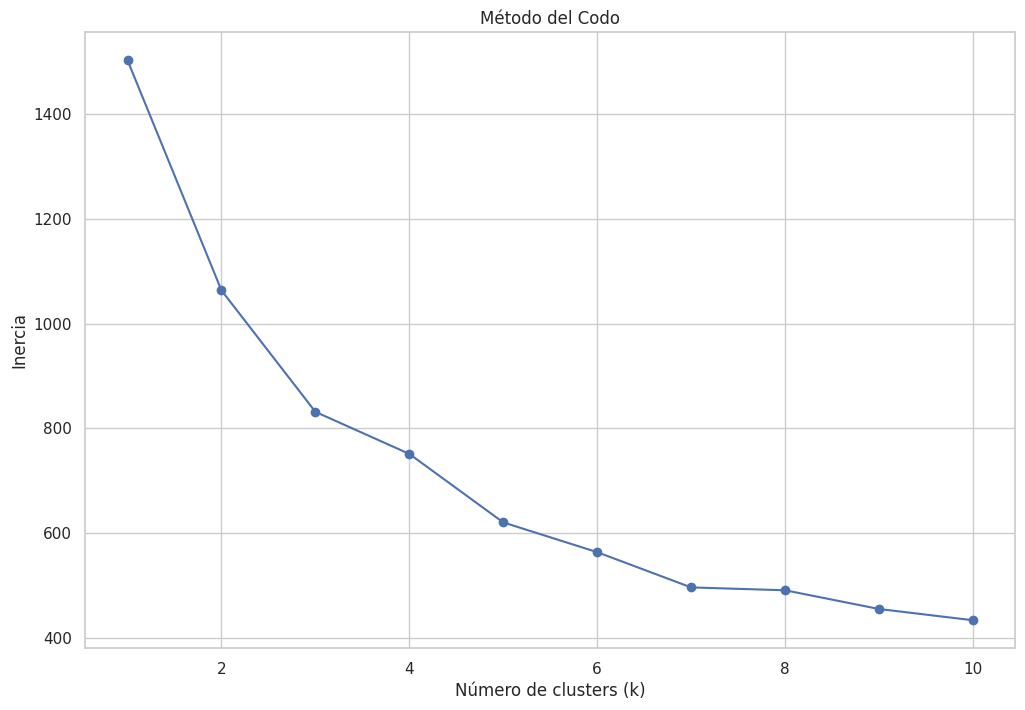

In [ ]:
inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Gráfica
plt.figure()
plt.plot(K, inertia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

2. ¿Dónde está el "codo"? ¿Qué número de clusters (k) parece ser el más adecuado? Justifiquen su elección.

El codo se observa aproximadamente en k = 3, ya que hasta este punto la inercia disminuye de forma pronunciada. A partir de k = 3, la reducción de la inercia es más gradual, lo que indica que agregar más clusters no genera mejoras significativas en el modelo. Por lo tanto, k = 3 parece ser el número más adecuado de clusters.

3. Calcula y grafica el coeficiente de silueta

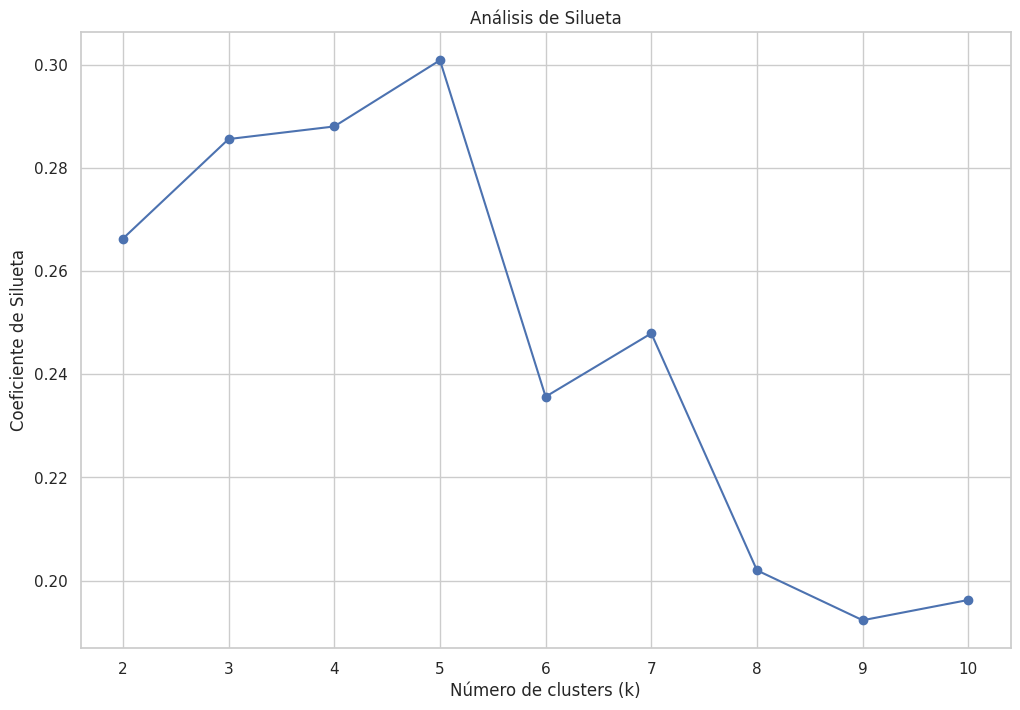

In [ ]:
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)

# Gráfica
plt.figure()
plt.plot(K, silhouette_scores, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Coeficiente de Silueta')
plt.title('Análisis de Silueta')
plt.show()

4. ¿Qué número de clusters (k) parece ser el más adecuado según el coeficiente de silueta? Justifiquen su elección.

El número de clusters más adecuado según el coeficiente de silueta es k = 5, ya que presenta el valor más alto (aproximadamente 0.30), lo que indica una mejor separación y cohesión entre los clusters en comparación con los demás valores de k.

5. Basados en los resultados del método del codo y el coeficiente de silueta, tomen una decisión de cuántos clusters usar. Justifiquen su elección.

El método del codo sugiere que el número óptimo de clusters es k = 3, ya que a partir de este punto la reducción de la inercia se vuelve menos significativa. Sin embargo, el coeficiente de silueta indica que k = 5 ofrece una mejor calidad de agrupamiento.
Considerando ambos métodos, se puede optar por k = 5, ya que proporciona clusters mejor definidos, aunque k = 3 también es una opción válida si se prioriza la simplicidad del modelo.

6. Aplica K-Means con el k que tu grupo eligió.

In [ ]:
kmeans_final = KMeans(n_clusters=5, random_state=42)

kmeans_final.fit(df_scaled)

clusters = kmeans_final.labels_

7. Añade la asignación de clusters al DataFrame original

In [ ]:
df['cluster'] = clusters

df.head()


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,Afghanistan,90.20,10.00,7.58,44.90,1610,9.44,56.20,5.82,553,2
1,Albania,16.60,28.00,6.55,48.60,9930,4.49,76.30,1.65,4090,0
2,Algeria,27.30,38.40,4.17,31.40,12900,16.10,76.50,2.89,4460,0
3,Angola,119.00,62.30,2.85,42.90,5900,22.40,60.10,6.16,3530,2
4,Antigua and Barbuda,10.30,45.50,6.03,58.90,19100,1.44,76.80,2.13,12200,0


## Ejercicio 5: Análisis e Interpretación de los Clusters

Ahora que tienes los grupos, necesitas entender qué los caracteriza.

1. Calcula el promedio de cada variable para cada cluster.
Esto te dará el "perfil" de cada grupo.

In [ ]:
cluster_profile = df.groupby('cluster').mean(numeric_only=True)

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,22.22,41.08,6.25,47.80,"12,678.97",7.73,72.63,2.33,"6,494.39"
1,5.18,46.12,9.09,40.58,"44,021.88",2.51,80.08,1.79,"42,118.75"
2,94.31,28.68,6.33,42.87,"3,503.25",9.90,59.02,5.05,"1,753.91"
3,130.00,25.30,5.07,17.40,"5,150.00",104.00,60.50,5.84,"2,330.00"
4,4.13,176.00,6.79,156.67,"64,033.33",2.47,81.43,1.38,"57,566.67"


2. Visualiza los resultados. Un scatter plot de 'gdpp' vs 'child_mort' es un buen punto de partida.

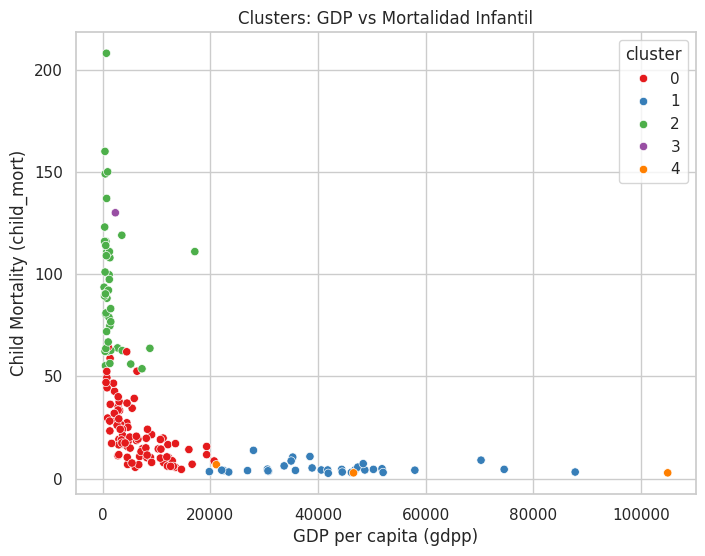

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='gdpp',
    y='child_mort',
    hue='cluster',
    palette='Set1'
)

plt.title('Clusters: GDP vs Mortalidad Infantil')
plt.xlabel('GDP per capita (gdpp)')
plt.ylabel('Child Mortality (child_mort)')

plt.show()

3. **Nombra los clusters:** Basado en el perfil de cada uno, dale un nombre descriptivo.


Cluster 0: Países en desarrollo

Cluster 1: Países desarrollados

Cluster 2: Países con bajo desarrollo

Cluster 3: Países en situación crítica

Cluster 4: Países altamente desarrollados

4. **Describe cada cluster:** Para cada grupo, describe sus características principales.


Cluster 0 (Países en desarrollo): Presentan ingresos y PIB moderados, con niveles intermedios de mortalidad infantil y esperanza de vida. Son economías en crecimiento con ciertas mejoras sociales.

Cluster 1 (Países desarrollados): Tienen altos niveles de ingreso y PIB, baja mortalidad infantil y alta esperanza de vida, lo que refleja buenas condiciones económicas y sociales.

Cluster 2 (Países con bajo desarrollo): Se caracterizan por bajos ingresos, alto nivel de mortalidad infantil y menor esperanza de vida, lo que indica condiciones de vulnerabilidad.

Cluster 3 (Países en situación crítica): Presentan los peores indicadores, como muy alta mortalidad infantil e inflación, junto con bajos niveles de desarrollo económico.

Cluster 4 (Países altamente desarrollados): Son economías con los mayores niveles de ingreso y PIB, muy baja mortalidad infantil y alta calidad de vida.

5. **Recomendación de Política:** Elije un cluster y propón un tipo de programa de ayuda o política pública que el PNUD podría implementar para ellos.

 El cluster 2 es el indicado, ya que presenta bajos niveles de ingreso, alta mortalidad infantil y menor esperanza de vida. Para este grupo, se recomienda que el PNUD implemente programas enfocados en el fortalecimiento del sistema de salud, acceso a educación básica y mejora en infraestructura. Asimismo, es importante promover políticas que impulsen el empleo formal y el desarrollo económico sostenible. Estas acciones contribuirían a mejorar la calidad de vida y reducir las brechas de desigualdad entre países.